In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import seaborn as sns
sns.set_style("whitegrid")

In [235]:
df = pd.read_csv("ReportInfectionStatsMalaria (3).csv")

In [236]:
df.head()

,Time,NodeID,IndividualID,Gender,AgeYears,InfectionID,Infectiousness,Duration,Hepatocytes,IRBCs,Gametocytes
0,18250,1,12845,M,41.87400,465441,0.000000,1,2,0,0
1,18250,1,16754,F,30.60270,462944,0.000855,126,0,477,1007401
2,18250,1,18089,M,26.86300,460201,0.000080,249,0,57544004,319690
3,18250,1,13,M,54.55590,464321,0.011124,59,0,26362902259,71100043
4,18250,1,24684,M,8.05479,465199,0.000000,14,0,170465866,0


In [237]:
# Groupby Infection ID, and compute mean infectiousness, std infectiousness, mean gametocytes, std gametocytes
foo = df.groupby("InfectionID").agg({"Infectiousness": ["mean", "std"], "Gametocytes": ["mean", "std"]})
foo.head()

Infectiousness             Gametocytes              
                      mean       std          mean           std
InfectionID                                                     
456218            0.000257  0.000349  3.959407e+05  5.444591e+05
456622            0.278177  0.250248  1.052803e+06  8.669385e+05
456923            0.000989  0.000762  1.303222e+06  1.077585e+06
457261            0.000435  0.000556  6.811703e+05  8.637838e+05
457270            0.000225  0.000493  3.221711e+05  4.394412e+05

Text(0, 0.5, 'Std gametocytes')

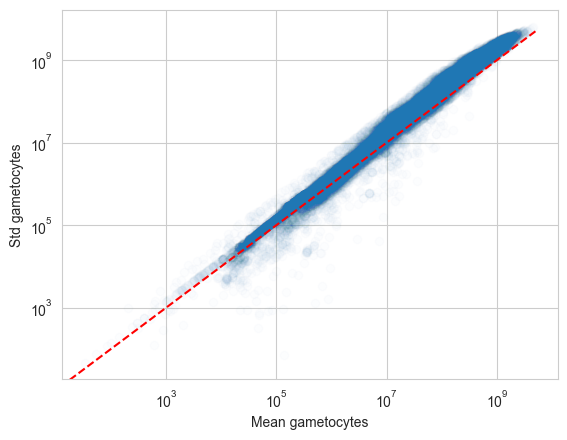

In [238]:
plt.scatter(foo["Gametocytes"]["mean"], foo["Gametocytes"]["std"], alpha=0.01)
# Plot identity line
plt.plot([0, 5e9], [0, 5e9], 'r--')
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Mean gametocytes")
plt.ylabel("Std gametocytes")

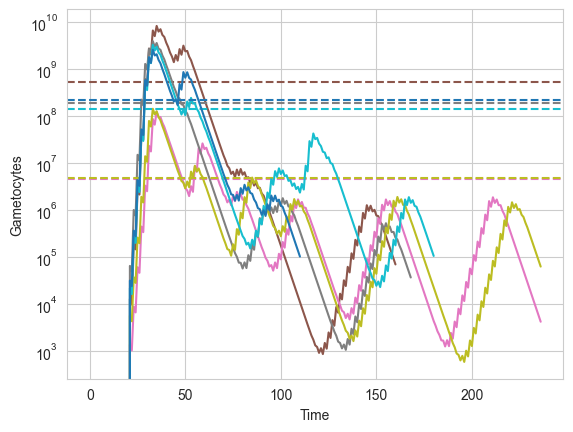

In [239]:
# Plot timeseries for first 10 infections
start_counter = 55
counter = 1
for i, group in df.groupby("InfectionID"):
    # Make sure we aren't looking at mid-course infections
    if np.min(group["Time"]) == 18250:
        continue
        
    if counter < start_counter:
        counter += 1
        continue
        
    if counter > 5 + start_counter:
        break
    color = f"C{counter}"
    plt.plot(group["Time"]-np.min(group["Time"]), group["Gametocytes"], c=color)
    plt.axhline(y=np.mean(group["Gametocytes"]), c=color, linestyle="--")
    plt.xlabel("Time")
    plt.ylabel("Gametocytes")
    counter += 1
    
    plt.yscale("log")

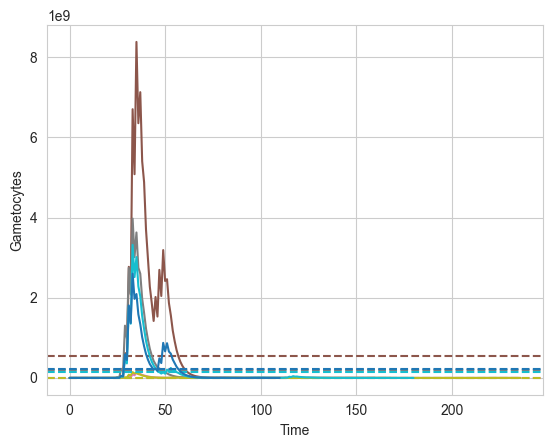

In [241]:
# Plot timeseries for first 10 infections
start_counter = 55
counter = 1
for i, group in df.groupby("InfectionID"):
    # Make sure we aren't looking at mid-course infections
    if np.min(group["Time"]) == 18250:
        continue
        
    if counter < start_counter:
        counter += 1
        continue
        
    if counter > 5 + start_counter:
        break
    color = f"C{counter}"
    plt.plot(group["Time"]-np.min(group["Time"]), group["Gametocytes"], c=color)
    plt.axhline(y=np.mean(group["Gametocytes"]), c=color, linestyle="--")
    plt.xlabel("Time")
    plt.ylabel("Gametocytes")
    counter += 1
    
    # plt.yscale("log")

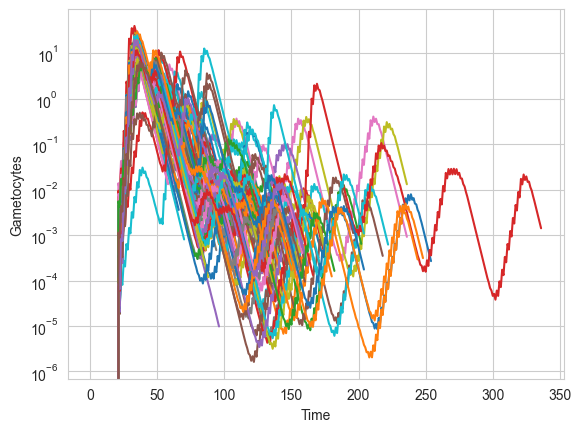

In [11]:
# Plot timeseries for first 10 infections, normalized by mean infectiousness
start_counter = 55
counter = 1
for i, group in df.groupby("InfectionID"):
    # Make sure we aren't looking at mid-course infections
    if np.min(group["Time"]) == 18250:
        continue
        
    if counter < start_counter:
        counter += 1
        continue
        
    if counter > 100 + start_counter:
        break
    color = f"C{counter}"
    plt.plot(group["Time"]-np.min(group["Time"]), group["Gametocytes"]/np.mean(group["Gametocytes"]), c=color)
    # plt.axhline(y=np.mean(group["Gametocytes"]), c=color, linestyle="--")
    plt.xlabel("Time")
    plt.ylabel("Gametocytes")
    counter += 1
    
    plt.yscale("log")

In [12]:
df.columns

Index(['Time', 'NodeID', 'IndividualID', 'Gender', 'AgeYears', 'InfectionID',
       'Infectiousness', 'Duration', 'Hepatocytes', 'IRBCs', 'Gametocytes'],
      dtype='object')

KeyboardInterrupt: 

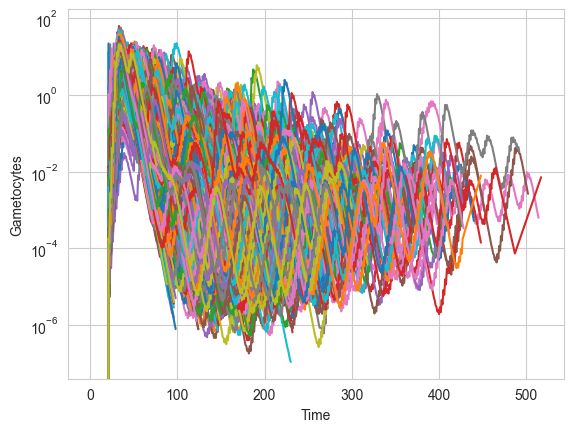

In [13]:

for i, group in df.groupby("InfectionID"):
    # Make sure we aren't looking at mid-course infections
    if np.min(group["Time"]) == 18250:
        continue
    
    # Find height of first local maximum in gametocytes for each infection
    
        
    color = f"C{counter}"
    plt.plot(group["Time"]-np.min(group["Time"]), group["Gametocytes"]/np.mean(group["Gametocytes"]), c=color)
    # plt.axhline(y=np.mean(group["Gametocytes"]), c=color, linestyle="--")
    plt.xlabel("Time")
    plt.ylabel("Gametocytes")
    counter += 1
    
    plt.yscale("log")

In [40]:
from scipy.stats import linregress
def get_slope_with_logtransform(x,y):
    slope, intercept, r_value, p_value, std_err = linregress(x, np.log(y))
    y_fitted = np.exp(intercept + slope*x)
    return slope, intercept, y_fitted

34


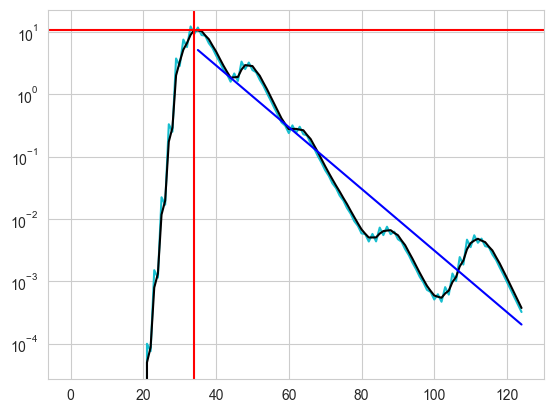

In [43]:
group["Time_Infection"] = group["Time"] - np.min(group["Time"])
group["Gametocytes_normalized"] = group["Gametocytes"]/np.mean(group["Gametocytes"])
group["Gametocytes_normalized_smoothed"] = group["Gametocytes_normalized"].rolling(window=2).mean()
plt.plot(group["Time_Infection"], group["Gametocytes_normalized"], c=color)
plt.yscale("log")

# Smooth Gametocytes on a rolling window with 2-day timescale
plt.plot(group["Time_Infection"], group["Gametocytes_normalized_smoothed"], c="k")

def find_first_local_maximum(time, height):
    # Compute the difference array
    diff = np.diff(height)
    
    # Find where the difference changes from positive to negative
    for i in range(1, len(diff)):
        if diff[i-1] > 0 and diff[i] <= 0:
            print(i)
            return time[i], height[i]
    
    return None, None

t_first_max, h_first_max = find_first_local_maximum(group["Time_Infection"].values, group["Gametocytes_normalized_smoothed"].values)

# Fit a line to the timeseries after the first maximum
group_after_max = group[group["Time_Infection"] > t_first_max]

# Do linear regression between group_after_max["Time"] and group_after_max["Gametocytes_smoothed"]
# from scipy.stats import linregress
# slope, intercept, r_value, p_value, std_err = linregress(group_after_max["Time_Infection"], group_after_max["Gametocytes_normalized_smoothed"])

slope, intercept, y_fitted = get_slope_with_logtransform(group_after_max["Time_Infection"], group_after_max["Gametocytes_normalized_smoothed"])

plt.axvline(x=t_first_max, c="r")
plt.axhline(y=h_first_max, c="r")

# Plot regression
# plt.plot(group_after_max["Time_Infection"], group_after_max["Gametocytes_normalized_smoothed"], c="b")
plt.plot(group_after_max["Time_Infection"], np.exp(slope*group_after_max["Time_Infection"] + intercept), c="b")

In [51]:
def fit_log_slope_under_constraint(time, height, constraint_time, constraint_height):
    log_height = np.log(height)
    log_constraint_height = np.log(constraint_height)
    
    def cost(m):
        # Constraint reduces problem to a single variable, using y=mx+b
        b = log_constraint_height - m*constraint_time
        
        # Compute cost as sum of squared differences
        log_height_pred = m*time + b
        return np.sum((log_height - log_height_pred)**2)
    
    from scipy.optimize import minimize
    res = minimize(cost, 0)
    
    m = res["x"][0]
    b = log_constraint_height - m*constraint_time
    
    return m,b

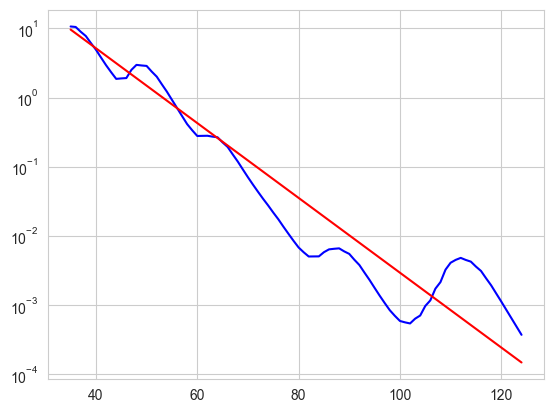

In [52]:
m,b = fit_log_slope_under_constraint(group_after_max["Time_Infection"], group_after_max["Gametocytes_normalized_smoothed"], t_first_max, h_first_max) 
plt.plot(group_after_max["Time_Infection"], group_after_max["Gametocytes_normalized_smoothed"], c="b")
plt.yscale("log")

plt.plot(group_after_max["Time_Infection"], np.exp(m*group_after_max["Time_Infection"]+b), c="r")

34


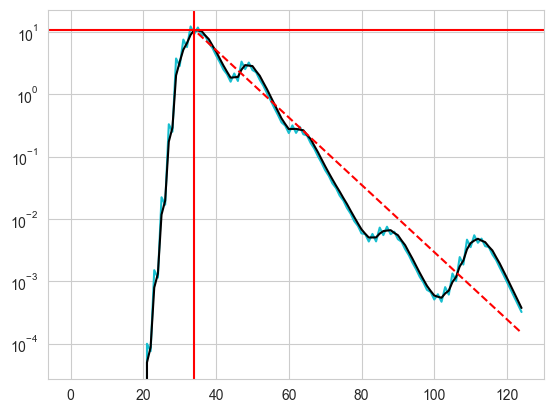

In [55]:
group["Time_Infection"] = group["Time"] - np.min(group["Time"])
group["Gametocytes_normalized"] = group["Gametocytes"]/np.mean(group["Gametocytes"])
group["Gametocytes_normalized_smoothed"] = group["Gametocytes_normalized"].rolling(window=2).mean()
plt.plot(group["Time_Infection"], group["Gametocytes_normalized"], c=color)
plt.yscale("log")

# Smooth Gametocytes on a rolling window with 2-day timescale
plt.plot(group["Time_Infection"], group["Gametocytes_normalized_smoothed"], c="k")

def find_first_local_maximum(time, height):
    # Compute the difference array
    diff = np.diff(height)
    
    # Find where the difference changes from positive to negative
    for i in range(1, len(diff)):
        if diff[i-1] > 0 and diff[i] <= 0:
            print(i)
            return time[i], height[i]
    
    return None, None

t_first_max, h_first_max = find_first_local_maximum(group["Time_Infection"].values, group["Gametocytes_normalized_smoothed"].values)

# Fit a line to the timeseries after the first maximum
group_after_max = group[group["Time_Infection"] > t_first_max]

# Do linear regression between group_after_max["Time"] and group_after_max["Gametocytes_smoothed"]
# from scipy.stats import linregress
# slope, intercept, r_value, p_value, std_err = linregress(group_after_max["Time_Infection"], group_after_max["Gametocytes_normalized_smoothed"])

plt.axvline(x=t_first_max, c="r")
plt.axhline(y=h_first_max, c="r")

m,b = fit_log_slope_under_constraint(group_after_max["Time_Infection"], group_after_max["Gametocytes_normalized_smoothed"], t_first_max, h_first_max) 
# plt.plot(group_after_max["Time_Infection"], group_after_max["Gametocytes_normalized_smoothed"], c="b")
# plt.yscale("log")

plt.plot(group_after_max["Time_Infection"], np.exp(m*group_after_max["Time_Infection"]+b), c="r", linestyle="--")

36
16.06592109952721
-0.14587080529848145
0.4833421706058111
0.0010823507374159832


Text(0.5, 0, 'Days since infection start')

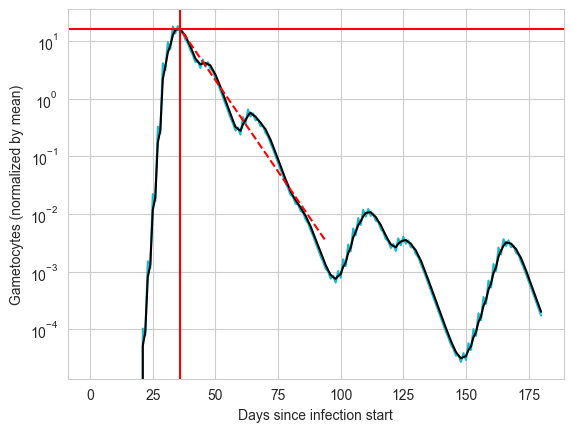

In [84]:
counter = 0
for i, group in df.groupby("InfectionID"):
    # Make sure we aren't looking at mid-course infections
    if np.min(group["Time"]) != 18250:
        counter += 1
        if counter == 18:
            break

group["Time_Infection"] = group["Time"] - np.min(group["Time"])
group["Gametocytes_normalized"] = group["Gametocytes"]/np.mean(group["Gametocytes"])
group["Gametocytes_normalized_smoothed"] = group["Gametocytes_normalized"].rolling(window=2).mean()
plt.plot(group["Time_Infection"], group["Gametocytes_normalized"], c=color)
plt.yscale("log")

# Smooth Gametocytes on a rolling window with 2-day timescale
plt.plot(group["Time_Infection"], group["Gametocytes_normalized_smoothed"], c="k")

def find_first_local_maximum(time, height):
    # Compute the difference array
    diff = np.diff(height)
    
    # Find where the difference changes from positive to negative
    for i in range(1, len(diff)):
        if diff[i-1] > 0 and diff[i] <= 0:
            return time[i], height[i]
    
    return None, None

t_first_max, h_first_max = find_first_local_maximum(group["Time_Infection"].values, group["Gametocytes_normalized_smoothed"].values)

# Fit a line to the timeseries after the first maximum, but before the first crossing with 1e-3
group_after_max = group[group["Time_Infection"] > t_first_max]

t_crossing = None
for i in range(1, len(group_after_max)):
    if group_after_max["Gametocytes_normalized"].values[i] < 1e-3:
        t_crossing = group_after_max["Time_Infection"].values[i]
        break

if t_crossing is None:
    group_of_interest = group_after_max
else:
    group_of_interest = group_after_max[group_after_max["Time_Infection"] < t_crossing]


# Do linear regression between group_after_max["Time"] and group_after_max["Gametocytes_smoothed"]
# from scipy.stats import linregress
# slope, intercept, r_value, p_value, std_err = linregress(group_after_max["Time_Infection"], group_after_max["Gametocytes_normalized_smoothed"])

plt.axvline(x=t_first_max, c="r")
plt.axhline(y=h_first_max, c="r")

m,b = fit_log_slope_under_constraint(group_of_interest["Time_Infection"], group_of_interest["Gametocytes_normalized_smoothed"], t_first_max, h_first_max) 
# plt.plot(group_after_max["Time_Infection"], group_after_max["Gametocytes_normalized_smoothed"], c="b")
# plt.yscale("log")

plt.plot(group_of_interest["Time_Infection"], np.exp(m*group_of_interest["Time_Infection"]+b), c="r", linestyle="--")

print(t_first_max)
print(h_first_max)
print(m)

# Calculate total at max and 10 days later
t_window = np.logical_and(group["Time_Infection"] > t_first_max-2, group["Time_Infection"] < t_first_max + 8)
total_near_max = np.sum(group["Gametocytes_normalized"][t_window])
print(total_near_max/np.sum(group["Gametocytes_normalized"]))

# How bad is it to ignore the tail?
if t_crossing is not None:
    print(np.sum(group["Gametocytes_normalized"][group["Time_Infection"] > t_crossing])/np.sum(group["Gametocytes_normalized"]))

plt.ylabel("Gametocytes (normalized by mean)")
plt.xlabel("Days since infection start")

In [118]:
# Get these metrics for all infections
t_first_max_list = []
h_first_max_list = []
m_list = []
age_list = []
infection_duration = []
mean_gametocyte_level = []

for i, group in df.groupby("InfectionID"):
    # Make sure we aren't looking at mid-course infections
    if np.min(group["Time"]) != 18250:
        group["Time_Infection"] = group["Time"] - np.min(group["Time"])
        group["Gametocytes_normalized"] = group["Gametocytes"]/np.mean(group["Gametocytes"])
        group["Gametocytes_normalized_smoothed"] = group["Gametocytes_normalized"].rolling(window=2).mean()

        t_first_max, h_first_max = find_first_local_maximum(group["Time_Infection"].values, group["Gametocytes_normalized_smoothed"].values)

        if t_first_max is None or h_first_max is None:
            continue

        # Fit a line to the timeseries after the first maximum, but before the first crossing with 1e-3
        group_after_max = group[group["Time_Infection"] > t_first_max]

        t_crossing = None
        for i in range(1, len(group_after_max)):
            if group_after_max["Gametocytes_normalized"].values[i] < 1e-3:
                t_crossing = group_after_max["Time_Infection"].values[i]
                break

        if t_crossing is None:
            group_of_interest = group_after_max
        else:
            group_of_interest = group_after_max[group_after_max["Time_Infection"] < t_crossing]

        m,b = fit_log_slope_under_constraint(group_of_interest["Time_Infection"], group_of_interest["Gametocytes_normalized_smoothed"], t_first_max, h_first_max) 

        age_list.append(np.mean(group["AgeYears"]))
        t_first_max_list.append(t_first_max)
        h_first_max_list.append(h_first_max)
        m_list.append(m)
        infection_duration.append(np.max(group["Time_Infection"]))
        mean_gametocyte_level.append(np.mean(group["Gametocytes"]))

KeyboardInterrupt: 

In [119]:
age_list = np.array(age_list)
t_first_max_list = np.array(t_first_max_list)
h_first_max_list = np.array(h_first_max_list)
m_list = np.array(m_list)

# Cap age at 80
age_list = np.minimum(age_list, 80)

(array([  1., 923.,   0., 760.,   0.,  96.,  84.,   0.,   4.,   0.,   1.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   1.]),
 array([32. , 33.2, 34.4, 35.6, 36.8, 38. , 39.2, 40.4, 41.6, 42.8, 44. ,
        45.2, 46.4, 47.6, 48.8, 50. , 51.2, 52.4, 53.6, 54.8, 56. ]),
 <BarContainer object of 20 artists>)

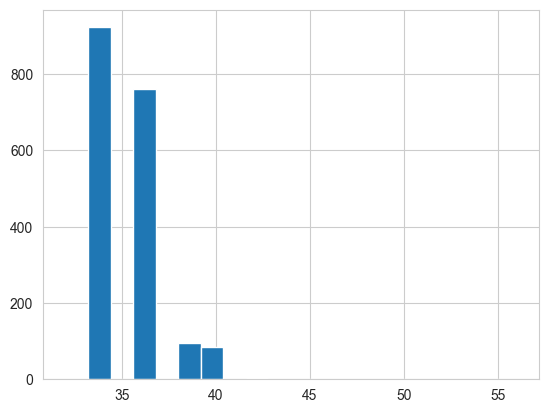

In [120]:
plt.hist(t_first_max_list, bins=20)

(array([ 26.,   8., 190., 365., 338., 325., 233., 146.,  88.,  61.,  42.,
         19.,   8.,   6.,   6.,   6.,   0.,   1.,   1.,   1.]),
 array([2.69318943e-02, 2.40939748e+00, 4.79186306e+00, 7.17432864e+00,
        9.55679423e+00, 1.19392598e+01, 1.43217254e+01, 1.67041910e+01,
        1.90866566e+01, 2.14691221e+01, 2.38515877e+01, 2.62340533e+01,
        2.86165189e+01, 3.09989845e+01, 3.33814501e+01, 3.57639156e+01,
        3.81463812e+01, 4.05288468e+01, 4.29113124e+01, 4.52937780e+01,
        4.76762436e+01]),
 <BarContainer object of 20 artists>)

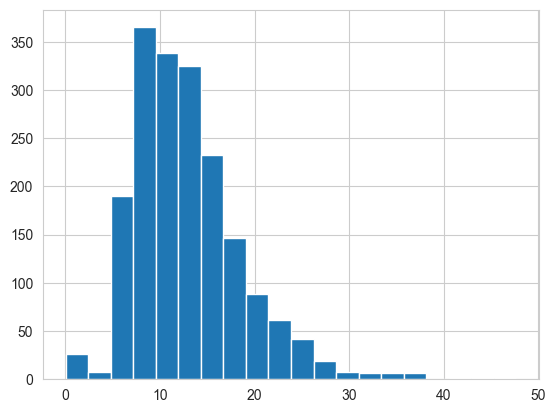

In [121]:
plt.hist(h_first_max_list, bins=20)

(array([ 60.,  92., 109.,  61.,  70.,  66.,  64., 225., 365., 186., 205.,
        184., 113.,  35.,  12.,  10.,   6.,   2.,   2.,   3.]),
 array([-0.26615214, -0.25100729, -0.23586244, -0.22071758, -0.20557273,
        -0.19042788, -0.17528303, -0.16013818, -0.14499333, -0.12984847,
        -0.11470362, -0.09955877, -0.08441392, -0.06926907, -0.05412422,
        -0.03897936, -0.02383451, -0.00868966,  0.00645519,  0.02160004,
         0.03674489]),
 <BarContainer object of 20 artists>)

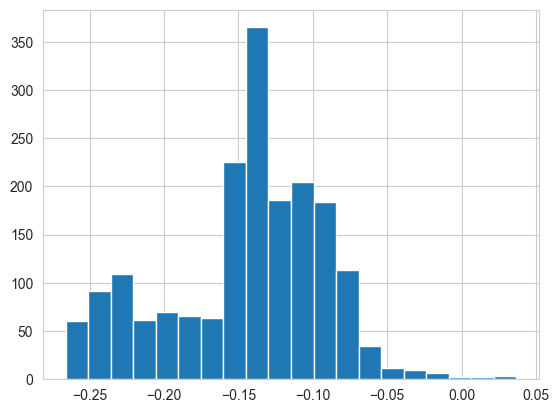

In [122]:
plt.hist(m_list, bins=20)

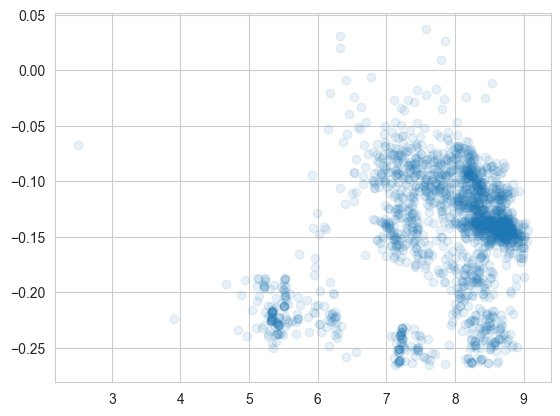

In [125]:
plt.scatter(np.log10(mean_gametocyte_level), m_list, alpha=0.1)

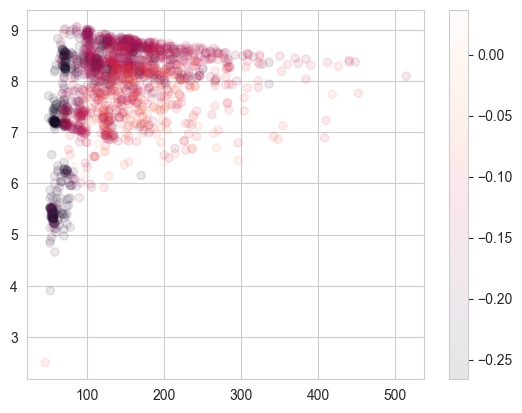

In [129]:
plt.scatter(infection_duration, np.log10(mean_gametocyte_level), c=m_list, alpha=0.1)
plt.colorbar()

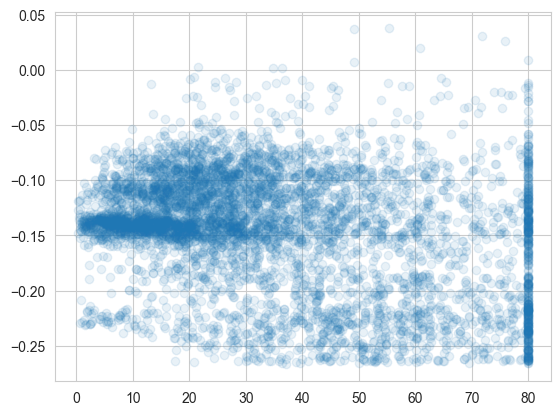

In [114]:
plt.scatter(age_list, m_list, alpha=0.1)

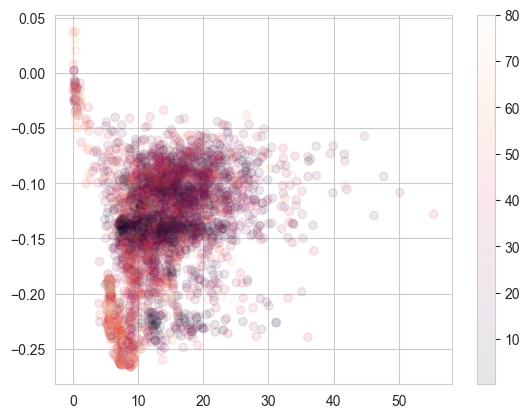

In [115]:
plt.scatter(h_first_max_list, m_list, alpha=0.1, c=age_list)
plt.colorbar()

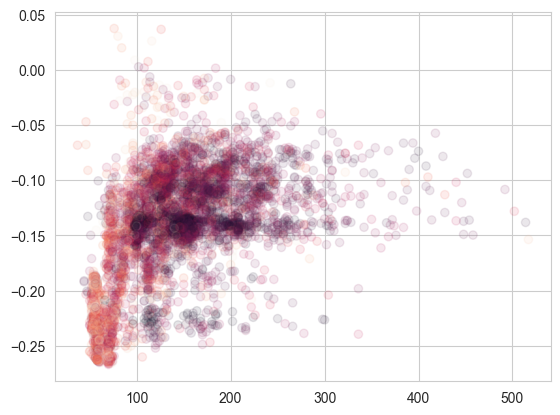

In [116]:
plt.scatter(infection_duration, m_list, alpha=0.1, c=age_list)

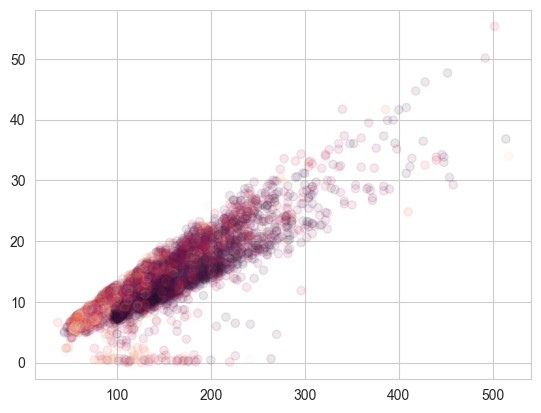

In [117]:
plt.scatter(infection_duration, h_first_max_list, alpha=0.1, c=age_list)

In [25]:
find_first_local_maximum(group["Time"].values, group["Gametocytes_smoothed"].values)

34


(18490, 7419782586.5)

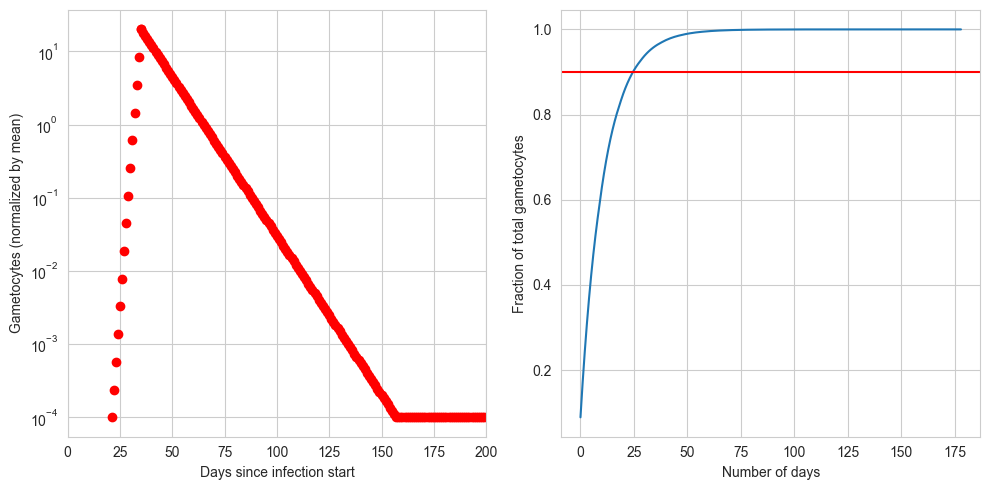

In [4]:
def plot_model_fit(t_first_max, duration, m, y_floor=1e-4):
    # Gametocytes show up after 21 days and rise rapidly to first peak
    t_start = 21
    h_start = 1e-4
    
    h_first_max = duration/10
    
    # y = np.exp(mx+b)
    m_rise = (np.log(h_first_max) - np.log(h_start)) / (t_first_max - t_start)
    b = np.log(h_start) - m_rise*t_start
    y = np.exp(m_rise*np.arange(t_start, t_first_max) + b)
    
    # Gametocytes rapidly decay after first peak
    b = np.log(h_first_max) - m*t_first_max
    y2 = np.exp(m*np.arange(t_first_max, duration) + b)
    y2 = np.maximum(y2, y_floor)
    
    plt.figure(figsize=(10,5))
    plt.subplot(1,2,1)
    plt.scatter(np.arange(t_start, t_first_max), y, c="r")
    plt.scatter(t_first_max, h_first_max, c="r")
    plt.scatter(np.arange(t_first_max, duration), y2, c="r")
    plt.yscale("log")
    plt.xlim([0,duration])
    plt.xlabel("Days since infection start")
    plt.ylabel("Gametocytes (normalized by mean)")
    
    y_full = np.concatenate([y, y2])
    y_full = np.maximum(y_full, y_floor)
    
    plt.subplot(1,2,2)
    plt.plot(np.cumsum(np.sort(y_full)[::-1])/np.sum(y_full))
    plt.axhline(y=0.9, c="r")
    plt.xlabel("Number of days")
    plt.ylabel("Fraction of total gametocytes")
    
    plt.tight_layout()
    plt.show()
    
    

    
    return y_full
    
    

y = plot_model_fit(t_first_max=35, duration=200, m=-0.1)


In [5]:
from functools import partial
import math

def expcdf(x, lmbda=1):
    if x < 0:
        return 0
    else:
        return 1 - math.exp(-lmbda * x)
    
def get_inv_micro_liters_blood(age_years):
    age_effective = min(age_years, 20)
    return 1e-6/(0.225*age_effective + 0.5)

base_gametocyte_mosquito_survival = 0.002011099

def infectiousness_from_gametocytes(n_gametocytes, age_years):
    inv_microliters_blood = get_inv_micro_liters_blood(age_years)
    microliters_per_bloodmeal = 1    
    fever_effect = 0
    return expcdf(n_gametocytes * inv_microliters_blood * microliters_per_bloodmeal * base_gametocyte_mosquito_survival * (1.0 - fever_effect))

# infectiousness_from_gametocytes = np.vectorize(partial(infectiousness_from_gametocytes, age_years=10))

In [221]:
foo = partial(infectiousness_from_gametocytes, age_years=10)
bar = np.vectorize(foo)

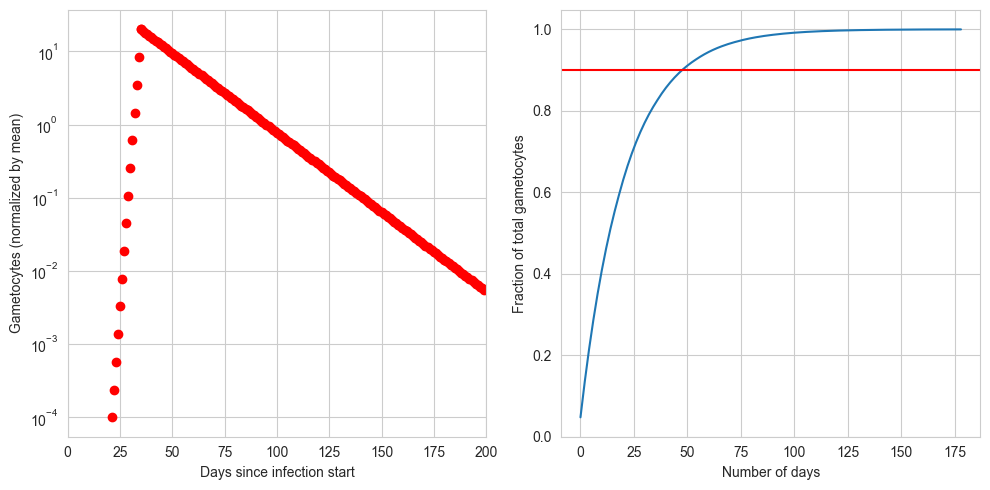

Mean y =  2.3706734246256254


Text(0, 0.5, 'Infectiousness')

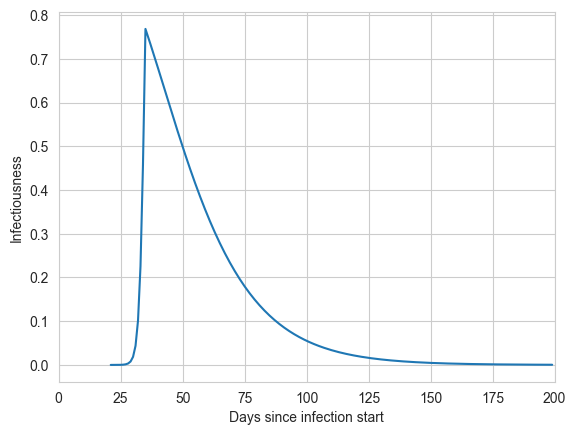

In [242]:
duration = 200
mean_g = 10**8
y = plot_model_fit(t_first_max=35, duration=duration, m=-0.05)

print("Mean y = ",np.mean(y))

g = y*mean_g

i = bar(g)
# plt.axhline(np.mean(i), c="k", linestyle='--')
plt.plot(np.arange(21, duration), i)
# plt.axhline(bar(mean_g), linestyle='dotted', c="C1")
plt.xlim([0,duration])
plt.xlabel("Days since infection start")
plt.ylabel("Infectiousness")

# print(bar(mean_g))

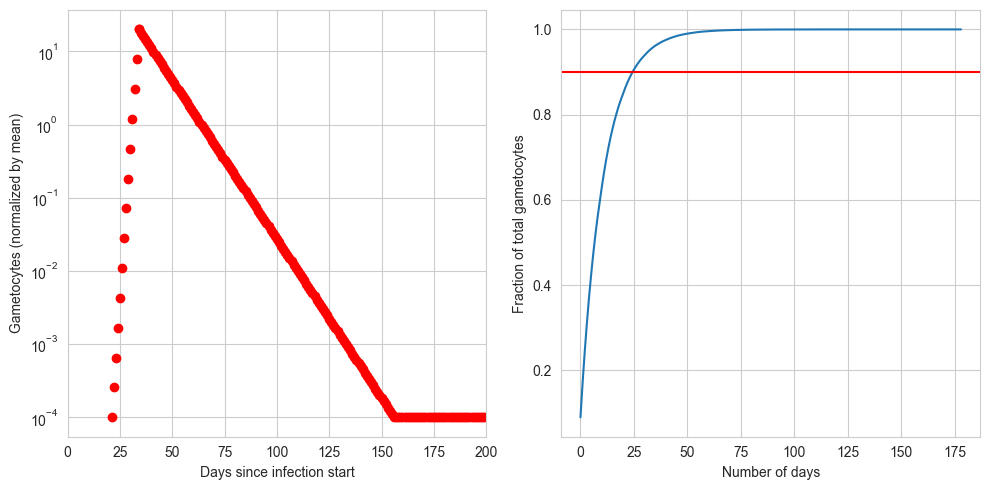

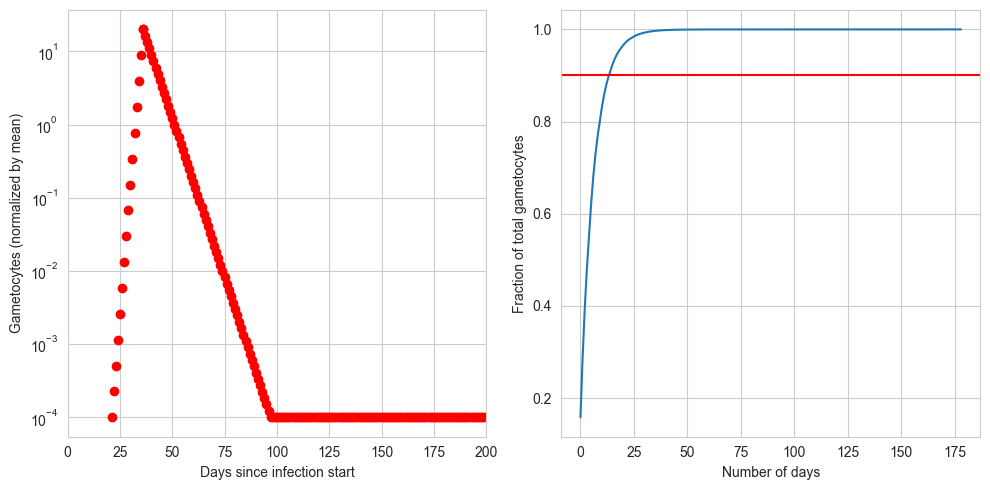

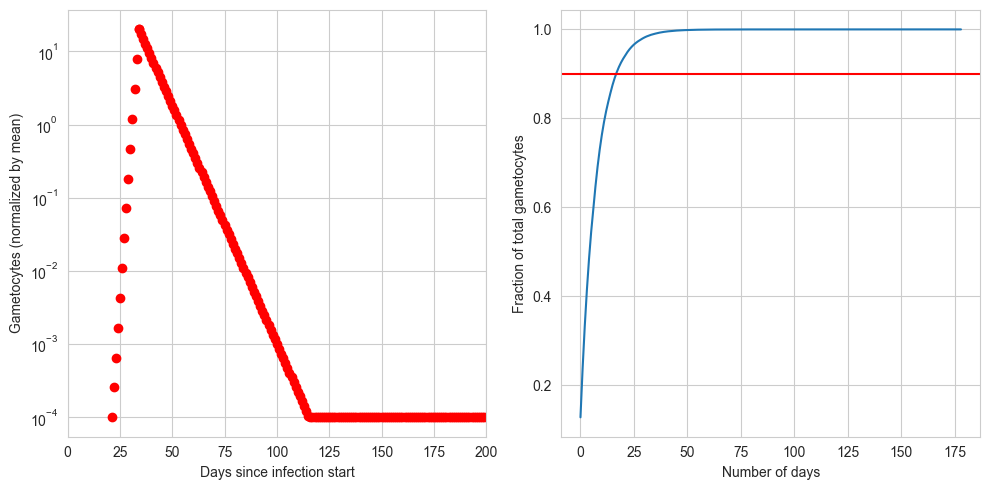

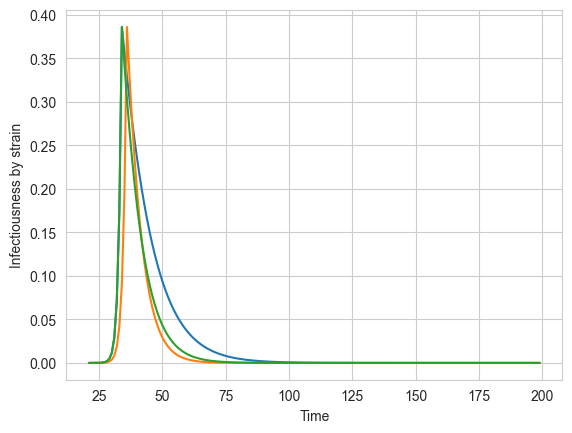

Text(0, 0.5, 'Probability that oocyst is clone of a parent strain')

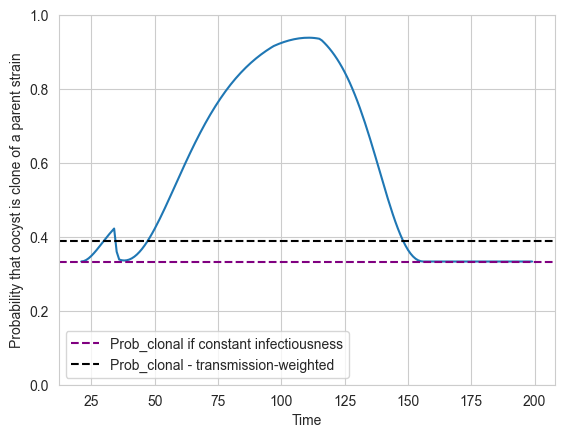

In [245]:
# Let's take 3 cotransmitted strains
duration = 200
mean_g = 10**8/3

y1 = plot_model_fit(t_first_max=34, duration=duration, m=-0.1)
y2 = plot_model_fit(t_first_max=36, duration=duration, m=-0.2)
y3 = plot_model_fit(t_first_max=34, duration=duration, m=-0.15)

# print("Mean y = ",np.mean(y))

g1 = y1*mean_g
g2 = y2*mean_g
g3 = y3*mean_g

i1 = bar(g1)
i2 = bar(g2)
i3 = bar(g3)
i_total = 1-(1-i1)*(1-i2)*(1-i3)

plt.figure()
plt.plot(np.arange(21, duration), i1)
plt.plot(np.arange(21, duration), i2)
plt.plot(np.arange(21, duration), i3)
# plt.plot(np.arange(21, duration), i_total, c="k", lw=2)
plt.xlabel("Time")
plt.ylabel("Infectiousness by strain")
plt.show()

plt.figure()
g_total = g1 + g2 + g3
prob_clonal = (g1/g_total)**2 + (g2/g_total)**2 + (g3/g_total)**2
prob_clonal_transmission_weighted = np.sum(i_total*prob_clonal)/np.sum(i_total)
plt.plot(np.arange(21, duration), prob_clonal)
plt.axhline(1/3, c="purple", linestyle='dashed', label="Prob_clonal if constant infectiousness")
plt.axhline(prob_clonal_transmission_weighted, c="k", linestyle='dashed', label="Prob_clonal - transmission-weighted")
plt.ylim([0,1])
plt.legend()
plt.xlabel("Time")
plt.ylabel("Probability that oocyst is clone of a parent strain")



# plt.axhline(bar(mean_g), linestyle='dotted', c="C1")
# plt.xlim([0,duration])
# plt.xlabel("Days since infection start")
# plt.ylabel("Infectiousness")
# 
# # print(bar(mean_g))

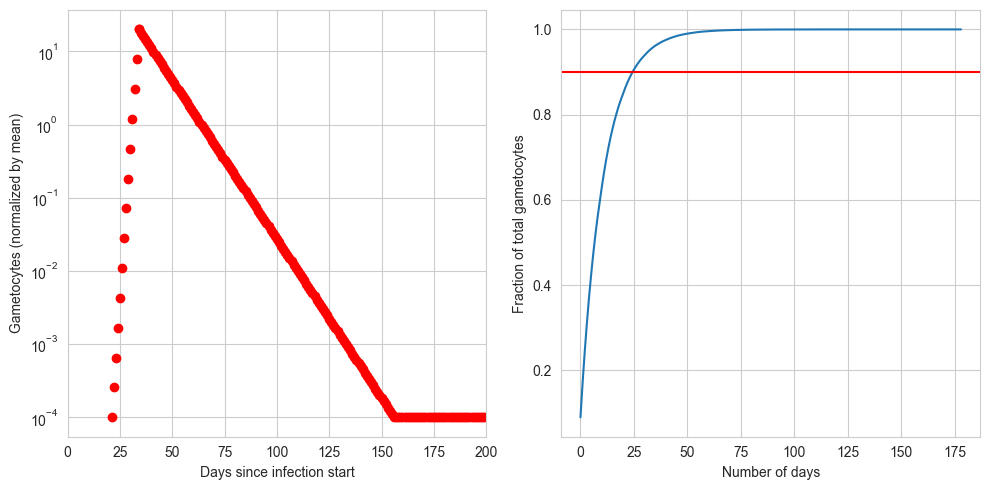

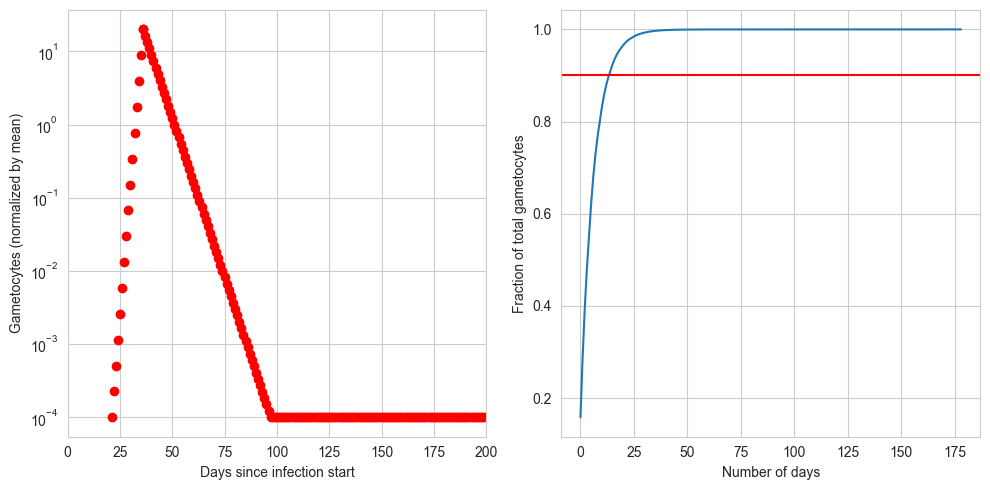

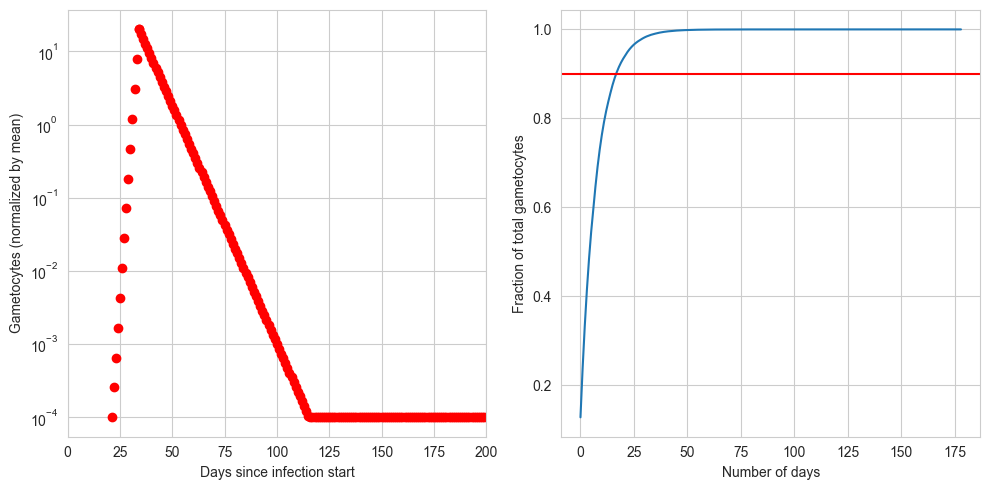

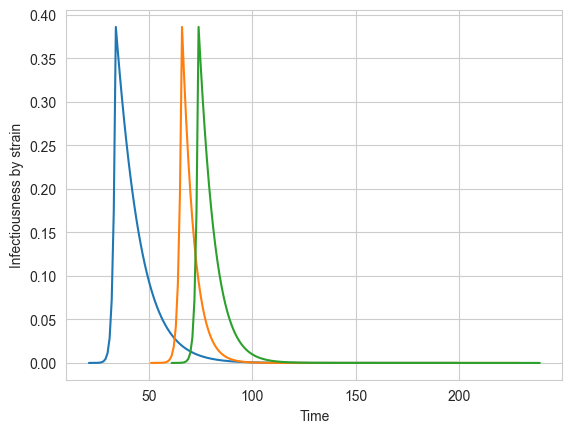

In [246]:
# Let's take 3 superinfected strains
duration = 200
mean_g = 10**8/3

y1 = plot_model_fit(t_first_max=34, duration=duration, m=-0.1)
y2 = plot_model_fit(t_first_max=36, duration=duration, m=-0.2)
y3 = plot_model_fit(t_first_max=34, duration=duration, m=-0.15)

t_offset_2 = 30
t_offset_3 = 40
# print("Mean y = ",np.mean(y))

g1 = y1*mean_g
g2 = y2*mean_g
g3 = y3*mean_g

i1 = bar(g1)
i2 = bar(g2)
i3 = bar(g3)
i_total = 1-(1-i1)*(1-i2)*(1-i3)

plt.figure()
plt.plot(np.arange(21, duration), i1)
plt.plot(np.arange(21 + t_offset_2, duration + t_offset_2), i2)
plt.plot(np.arange(21 + t_offset_3, duration + t_offset_3), i3)
# plt.plot(np.arange(21, duration), i_total, c="k", lw=2)
plt.xlabel("Time")
plt.ylabel("Infectiousness by strain")
plt.show()

df = pd.DataFrame({"t": np.array([0,300])})


# 
# plt.figure()
# g_total = g1 + g2 + g3
# prob_clonal = (g1/g_total)**2 + (g2/g_total)**2 + (g3/g_total)**2
# prob_clonal_transmission_weighted = np.sum(i_total*prob_clonal)/np.sum(i_total)
# plt.plot(np.arange(21, duration), prob_clonal)
# plt.axhline(1/3, c="purple", linestyle='dashed', label="Prob_clonal if constant infectiousness")
# plt.axhline(prob_clonal_transmission_weighted, c="k", linestyle='dashed', label="Prob_clonal - transmission-weighted")
# plt.ylim([0,1])
# plt.xlabel("Time")
# plt.ylabel("Probability that oocyst is clone of a parent strain")
# 


# plt.axhline(bar(mean_g), linestyle='dotted', c="C1")
# plt.xlim([0,duration])
# plt.xlabel("Days since infection start")
# plt.ylabel("Infectiousness")
# 
# # print(bar(mean_g))

In [229]:
np.sum(y1)/duration

1.115065755680472

In [230]:
np.sum(y2)/duration

0.6313110111816678

In [231]:
np.sum(y3)/duration

0.7821707747237032

In [232]:
np.sum(i1)/duration

0.024141931895261926

Text(0, 0.5, 'Fraction of total gametocytes')

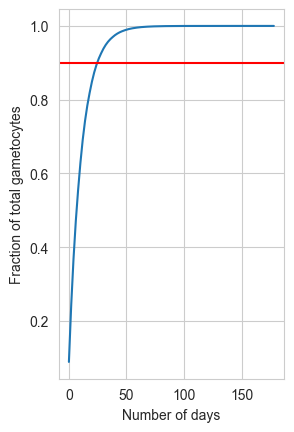

In [172]:
plt.subplot(1,2,2)
plt.plot(np.cumsum(np.sort(y)[::-1])/np.sum(y))
plt.axhline(y=0.9, c="r")
plt.xlabel("Number of days")
plt.ylabel("Fraction of total gametocytes")

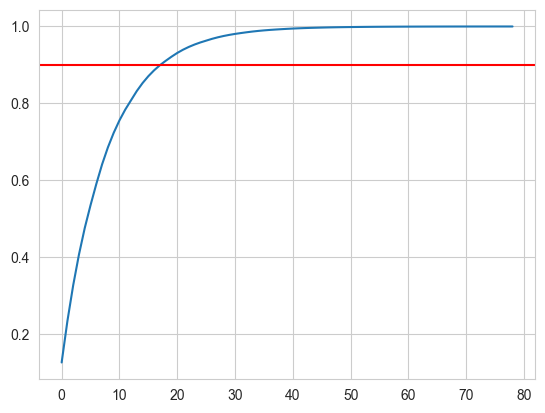

In [161]:
plt.plot(np.cumsum(np.sort(y)[::-1])/np.sum(y))
plt.axhline(y=0.9, c="r")
plt.xlabel("Number of days")
plt.ylabel("Fraction of total gametocytes")

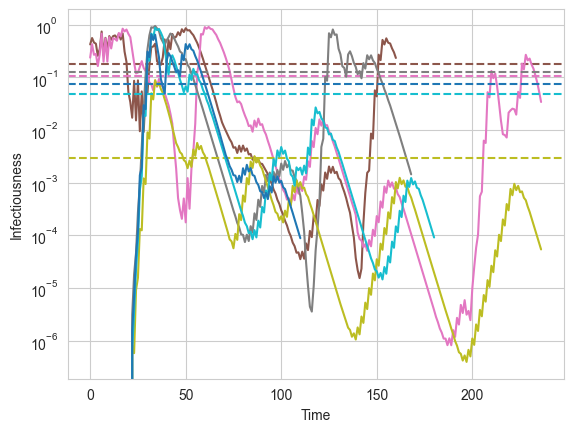

In [20]:
# Plot timeseries for first 10 infections
start_counter = 55
counter = 1
for i, group in df.groupby("InfectionID"):
    # Make sure we aren't looking at mid-course infections
    if np.min(group["Time"]) == 18250:
        continue
        
    if counter < start_counter:
        counter += 1
        continue
        
    if counter > 5 + start_counter:
        break
    color = f"C{counter}"
    plt.plot(group["Time"]-np.min(group["Time"]), group["Infectiousness"], c=color)
    plt.axhline(y=np.mean(group["Infectiousness"]), c=color, linestyle="--")
    plt.xlabel("Time")
    plt.ylabel("Infectiousness")
    counter += 1
    
    plt.yscale("log")

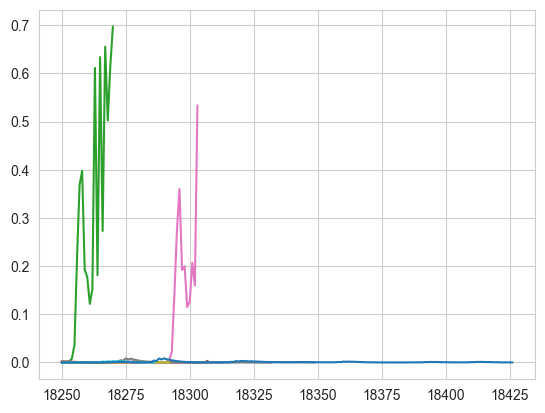

In [8]:
# Plot timeseries for first 10 infections
counter = 1
for i, group in df.groupby("InfectionID"):
    if counter > 10:
        break
    plt.plot(group["Time"], group["Infectiousness"], c=f"C{counter}")
    # plt.
    counter += 1

Try to write a sawtooth function which mimics this type of behavior:
1. mean =1 
2. period of 55
3. whose peak is 3 orders of magnitude higher than the trough

In [9]:
f = np.zeros(55)

In [10]:
f[0] = 1e-3
f[27] = 1
f[54] = 1e-3

print(f)

[0.001 0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.
 0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.
 0.    0.    0.    1.    0.    0.    0.    0.    0.    0.    0.    0.
 0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.
 0.    0.    0.    0.    0.    0.    0.001]


In [11]:
g = np.exp(np.log(1e3)/27)
print(g)

1.2915496650148839


In [12]:
for i in range(1, 27):
    print(i)
    f[i] = f[i-1] * g
print(f)
for i in range(28, 54):
    f[i] = f[i-1] / g
print(f)

1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
[0.001      0.00129155 0.0016681  0.00215443 0.00278256 0.00359381
 0.00464159 0.00599484 0.00774264 0.01       0.0129155  0.01668101
 0.02154435 0.02782559 0.03593814 0.04641589 0.05994843 0.07742637
 0.1        0.12915497 0.16681005 0.21544347 0.27825594 0.35938137
 0.46415888 0.59948425 0.77426368 1.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.001     ]
[0.001      0.00129155 0.0016681  0.00215443 0.00278256 0.00359381
 0.00464159 0.00599484 0.00774264 0.01       0.0129155  0.01668101
 0.02154435 0.02782559 0.03593814 0.04641589 0.05994843 0.07742637
 0.1        0.12915497 0.16681005 0.21544347 0.27825594 0.35938137
 0.46415888 0.59948425 0.77426368 1.         0.77426368 0.59948425
 0.46415888 0.359381

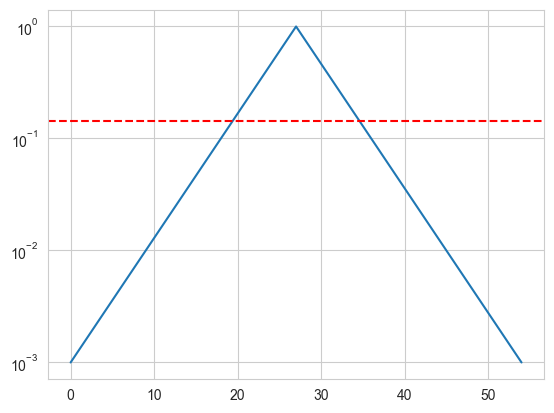

In [13]:
plt.plot(f)
plt.axhline(y=np.mean(f), c="r", linestyle="--")
plt.yscale("log")

In [14]:
# Rescale f to have mean 1
f = f / np.mean(f)

In [15]:
np.mean(f)

1.0000000000000002

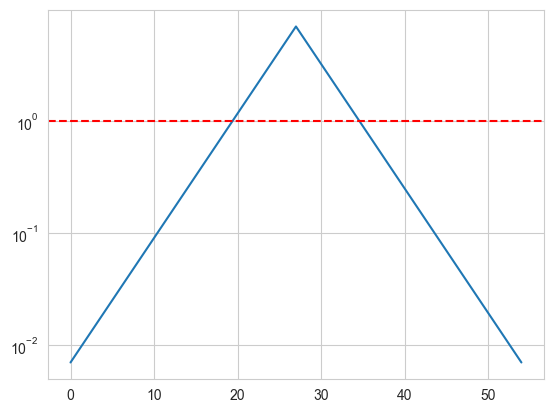

In [16]:
plt.plot(f)
plt.axhline(y=np.mean(f), c="r", linestyle="--")
plt.yscale("log")

In [1]:
# Plot timeseries for first 10 infections
start_counter = 15
counter = 1
for i, group in df.groupby("InfectionID"):
    if counter < start_counter:
        counter += 1
        continue
        
    if counter > 5 + start_counter:
        break
    color = f"C{counter}"
    plt.plot(group["Time"], group["Gametocytes"], c=color)
    plt.axhline(y=np.mean(group["Gametocytes"]), c=color, linestyle="--")
    plt.xlabel("Time")
    plt.ylabel("Gametocytes")
    counter += 1
    
    plt.yscale("log")
    
# Add plot of f
start_time = 18280
plt.plot(start_time + np.arange(len(f)), f*1e6, c="k")

NameError: name 'df' is not defined

In [79]:
np.mean(f[10:35])

2.0292257133405327

In [81]:
f.to_csv("sawtooth.csv", index=False)

AttributeError: 'numpy.ndarray' object has no attribute 'to_csv'

In [82]:
df_sawtooth = pd.DataFrame({"t": np.arange(55), "f": f})

In [83]:
df_sawtooth.to_csv("sawtooth.csv", index=False)

# EMOD infectiousness

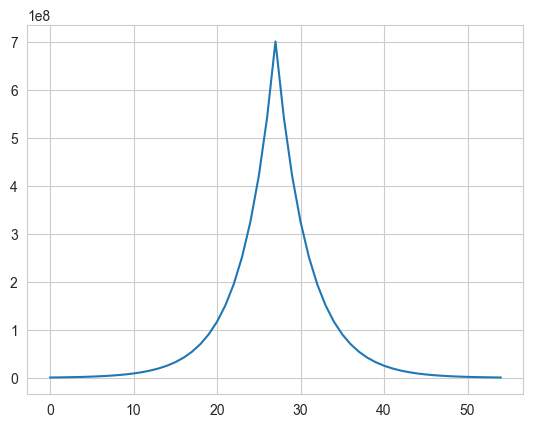

In [90]:
g = f*1e8
plt.plot(g)

In [88]:
import math

def expcdf(x, lmbda=1):
    if x < 0:
        return 0
    else:
        return 1 - math.exp(-lmbda * x)
    
def get_inv_micro_liters_blood(age_years):
    age_effective = min(age_years, 20)
    return 1e-6/(0.225*age_effective + 0.5)

base_gametocyte_mosquito_survival = 0.002011099

def infectiousness_from_gametocytes(n_gametocytes, age_years):
    inv_microliters_blood = get_inv_micro_liters_blood(age_years)
    microliters_per_bloodmeal = 1    
    fever_effect = 0
    return expcdf(n_gametocytes * inv_microliters_blood * microliters_per_bloodmeal * base_gametocyte_mosquito_survival * (1.0 - fever_effect))


In [91]:
infectiousness_from_gametocytes(1e8, 10)

0.07052082140950655

In [92]:
x = np.vectorize(infectiousness_from_gametocytes)

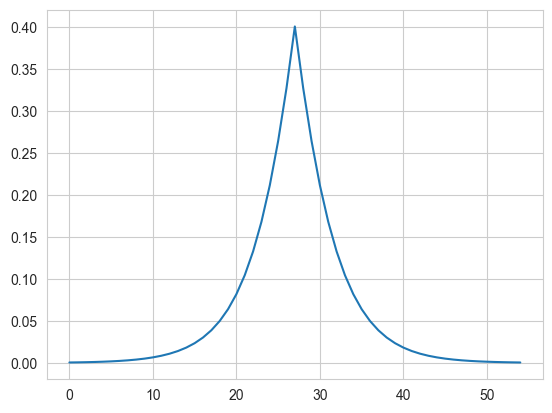

In [94]:
plt.plot(x(g,10))

In [95]:
np.mean(x(g,10))

0.06461758426026887

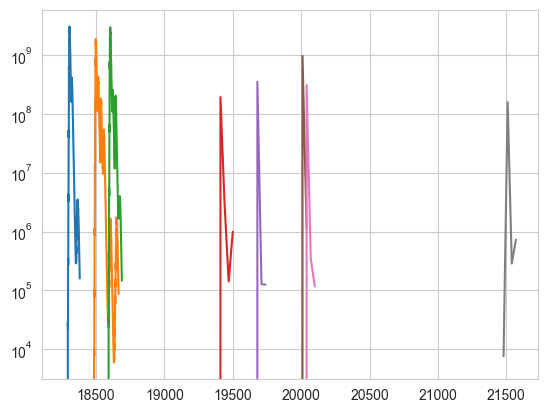

In [100]:
# Plot all infections from individual people

for i, group in df.groupby("IndividualID"):
    # Only plot if the person has more than 1 infection
    if len(group) > 1:
        # Plot each infection individually
        for j, group2 in group.groupby("InfectionID"):
            plt.plot(group2["Time"], group2["Gametocytes"])
        plt.yscale("log")
        break

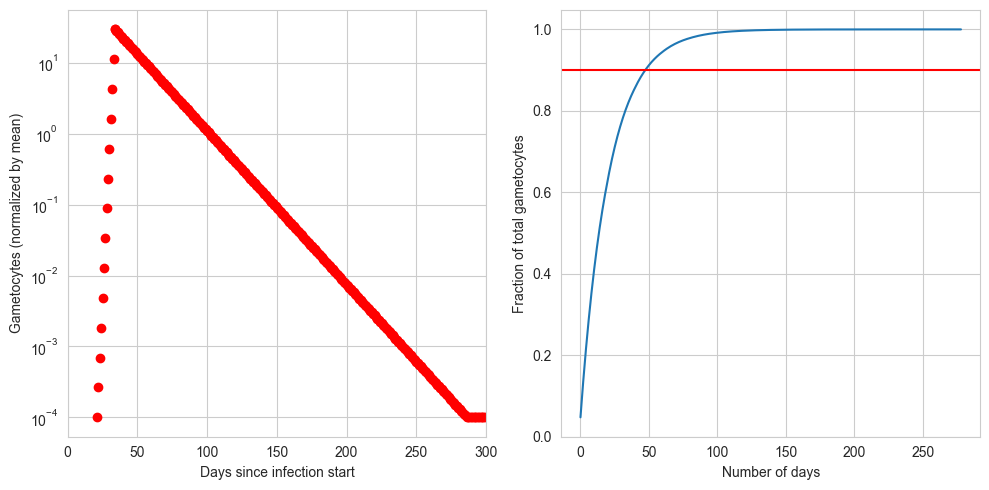

In [6]:
y1 = plot_model_fit(t_first_max=34, duration=300, m=-0.05)

In [8]:
np.mean(y1)

2.27038140238234

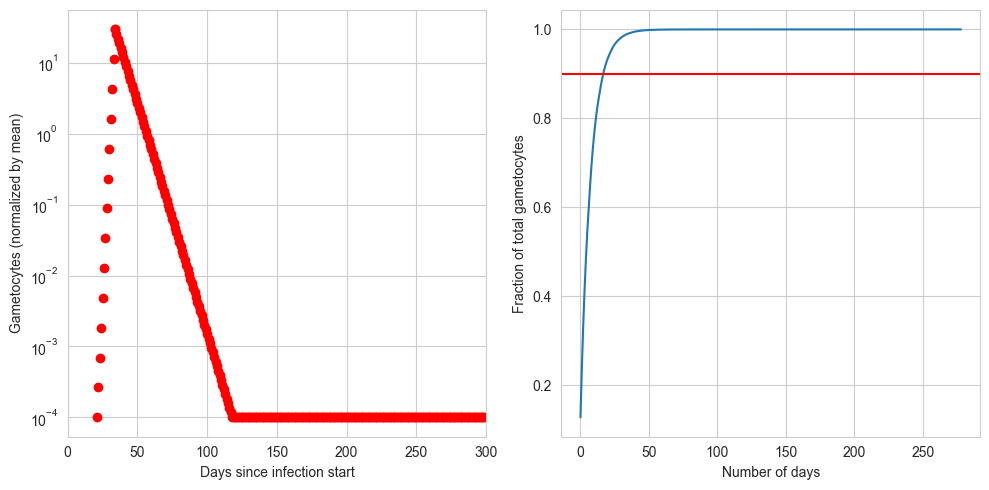

In [10]:
y1 = plot_model_fit(t_first_max=34, duration=300, m=-0.15)

In [11]:
np.mean(y1)

0.8376502648262913

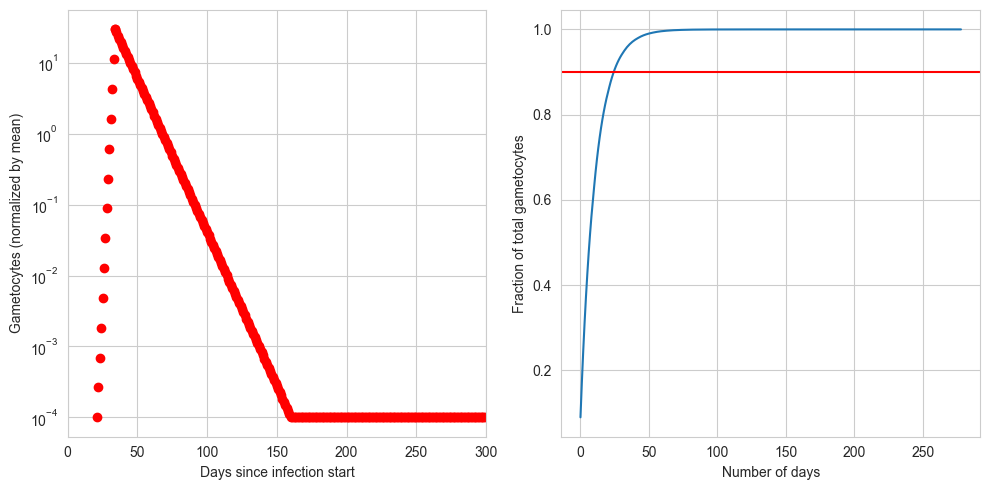

In [12]:
y1 = plot_model_fit(t_first_max=34, duration=300, m=-0.1)

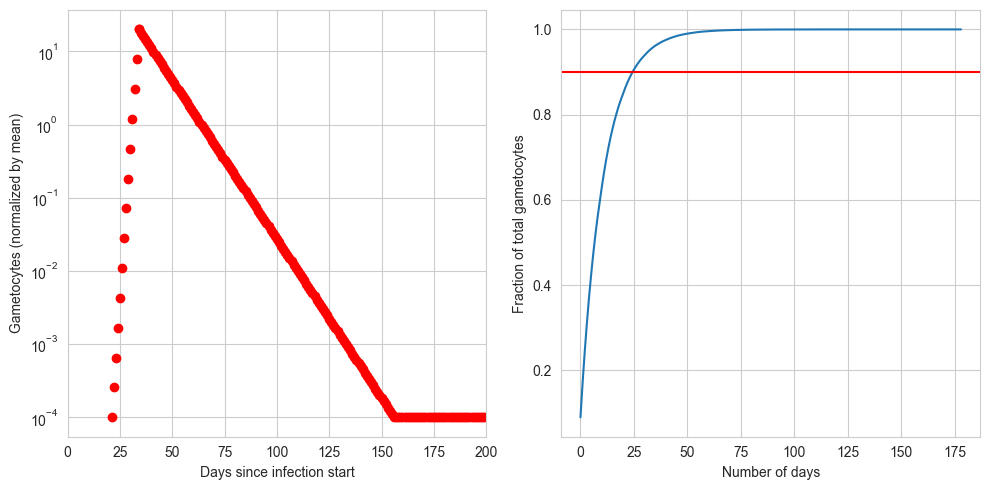

In [13]:
y1 = plot_model_fit(t_first_max=34, duration=200, m=-0.1)

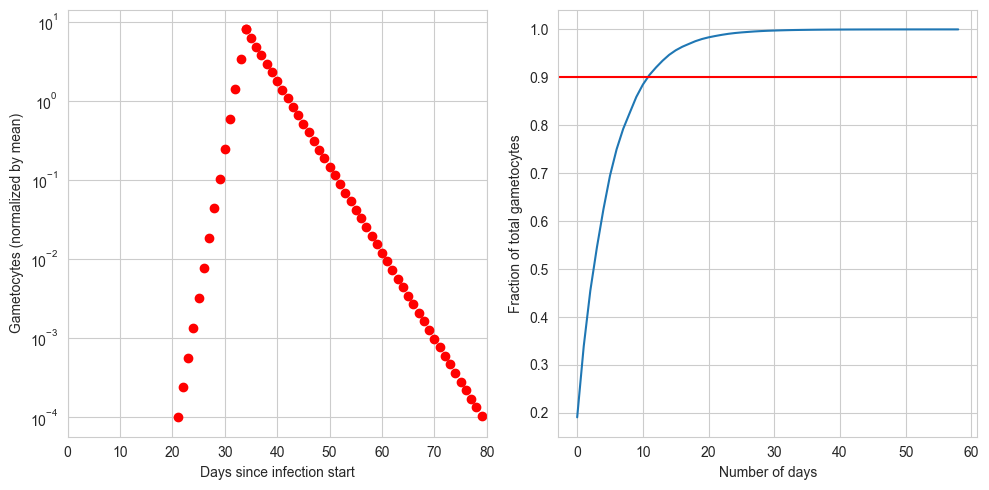

In [14]:
y1 = plot_model_fit(t_first_max=34, duration=80, m=-0.25)

# Try to define a single generic shape we can use for all infections

In [24]:
def fake_shape_1(duration, y_floor=1e-4):
    # Gametocytes show up after 21 days and rise rapidly to first peak, which is an integer uniformly drawn from [34,36]
    t_start = 21
    h_start = 1e-4
    
    t_first_max = np.random.randint(34,37)
    h_first_max = 15 # times the mean
    
    # y = np.exp(mx+b)
    m_rise = (np.log(h_first_max) - np.log(h_start)) / (t_first_max - t_start)
    b_rise = np.log(h_start) - m_rise*t_start
    y_rise = np.exp(m_rise*np.arange(t_start, t_first_max) + b_rise)
    
    # Gametocytes rapidly decay after first peak.
    # Slope is uniformly drawn from [-0.15,-0.07], and then stays at floor of y_floor
    # However, for very short infections, take more steep slow to ensure that we end at y_floor
    m_decay_max = (np.log(y_floor) - np.log(h_first_max)) / (duration - t_first_max)
    
    if m_decay_max < -0.15:
        m_decay = m_decay_max
    elif m_decay_max > -0.07:
        m_decay = np.random.uniform(-0.15, -0.07)
    else:
        m_decay = np.random.uniform(-0.15, m_decay_max)
        
    b_decay = np.log(h_first_max) - m_decay*t_first_max
    y_decay = np.exp(m_decay*np.arange(t_first_max, duration) + b_decay)
    
    y_rise_and_decay = np.concatenate([y_rise, y_decay])
    # Rescale to have mean of 1
    y_rise_and_decay = y_rise_and_decay / np.mean(y_rise_and_decay)
    
    # Now impose floor (note that doing this after the rescaling will not guarantee that the mean is 1, but it's close enough)
    y_rise_and_decay = np.maximum(y_rise_and_decay, y_floor)
    
    y_full = np.concatenate([np.zeros(t_start), y_rise_and_decay])
    
    return y_full

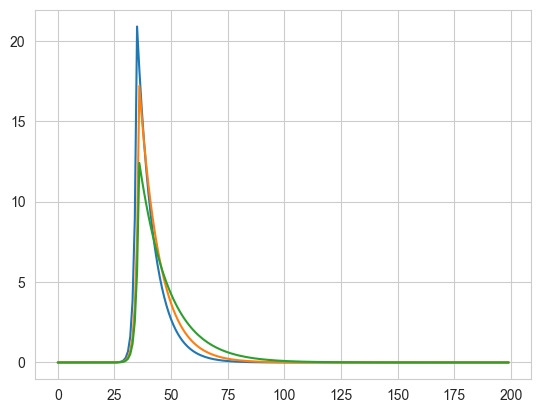

In [25]:
plt.plot(fake_shape_1(200))
plt.plot(fake_shape_1(200))
plt.plot(fake_shape_1(200))

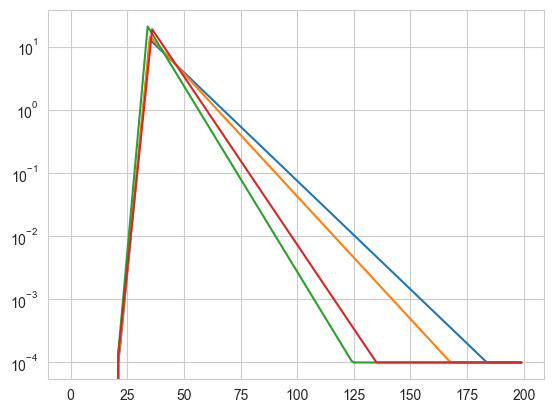

In [32]:
plt.plot(fake_shape_1(200))
plt.plot(fake_shape_1(200))
plt.plot(fake_shape_1(200))
plt.plot(fake_shape_1(200))
plt.yscale("log")

In [31]:
a = fake_shape_1(200)
np.mean(a[a>0])

1.0000349984046442

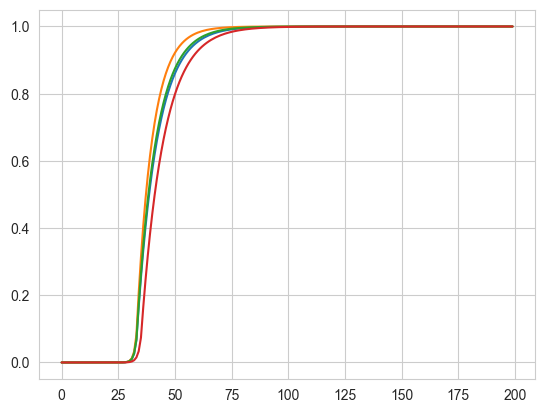

In [34]:
for i in range(4):
    a = fake_shape_1(200)
    plt.plot(np.cumsum(a)/np.sum(a))
# plt.yscale("log")